# Stock Price Prediction using RNN (LSTM)

**Name: Varad Kulkarni** 

**Class: TY-A-AIDS** 

**Roll No: A-56** 

**Course: Artificial Neural Networks & Deep Learning**

**Assignment: TA1**

**Dataset: Visa Inc. (V) — Yahoo Finance**

## Objective

The objective of this project is to predict future stock prices of Visa Inc. using a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) units.

The model learns from historical OHLCV data enriched with 8 technical indicators and forecasts the next day's closing price. A 30-day future price forecast is also generated using an autoregressive prediction loop.


---
## Task 0 — Install & Import Libraries

We install `yfinance` to fetch historical stock data and `ta` (Technical Analysis) to compute trading indicators like RSI, MACD, and Bollinger Bands without implementing them manually.


In [1]:
!pip install yfinance --quiet
!pip install ta --quiet        # Technical Analysis library

  Preparing metadata (setup.py) ... done


In [2]:
# ── Core libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ── Technical Analysis ────────────────────────────────────────────────────────
import ta
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend    import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models      import Sequential
from tensorflow.keras.layers      import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks   import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow version : 2.20.0
All libraries imported successfully!


---
## Task 1 — Data Preparation

### 1.1 Data Collection

We download historical stock data for **Visa Inc. (ticker: V)** from Yahoo Finance covering January 2019 to December 2024 — approximately 6 years of daily trading data. `auto_adjust=True` corrects prices for stock splits and dividends, ensuring price continuity.


In [3]:
# ── Download Visa stock data ──────────────────────────────────────────────────
ticker = "V"
df_raw = yf.download(ticker, start="2019-01-01", end="2024-12-31", auto_adjust=True)

# Flatten MultiIndex columns if present (newer yfinance versions)
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

print(f"Shape             : {df_raw.shape}")
print(f"Date range        : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
df_raw.head()

[*********************100%***********************]  1 of 1 completed

Shape             : (1509, 5)
Date range        : 2019-01-02 → 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,126.329475,127.108825,123.174097,123.554258,8788000
2019-01-03,121.776962,124.770771,121.539351,124.704249,9428300
2019-01-04,127.023232,127.916626,123.677774,123.972401,11065800
2019-01-07,129.313721,130.368684,127.393875,127.783549,12928000
2019-01-08,130.017029,131.338108,129.218682,131.129015,9243000


### 1.2 Feature Engineering — Technical Indicators

Instead of using only the raw closing price, we enrich the dataset with **8 technical indicators** commonly used by traders to identify trends, momentum, and volatility. This gives the LSTM richer context to learn from compared to price data alone.

| Indicator | What it captures |
|-----------|------------------|
| RSI (14)  | Overbought / oversold momentum |
| MACD      | Trend direction & strength |
| MACD Signal | Smoothed MACD crossover signal |
| Bollinger Upper/Lower | Volatility bands around price |
| EMA (20)  | Short-term exponential trend |
| SMA (50)  | Medium-term simple trend |
| ROC (10)  | Rate of price change (momentum) |
| Momentum  | Raw price momentum over 10 days |


In [4]:
# ── Build feature dataframe ───────────────────────────────────────────────────
df = df_raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

close = df['Close']

# ── 1. RSI (Relative Strength Index, 14-day) ──────────────────────────────────
# Measures whether the stock is overbought (>70) or oversold (<30)
df['RSI'] = RSIIndicator(close=close, window=14).rsi()

# ── 2. MACD (Moving Average Convergence Divergence) ───────────────────────────
# Captures trend direction: positive = bullish, negative = bearish
macd_obj = MACD(close=close, window_slow=26, window_fast=12, window_sign=9)
df['MACD']        = macd_obj.macd()
df['MACD_Signal'] = macd_obj.macd_signal()

# ── 3. Bollinger Bands (20-day, 2 std dev) ────────────────────────────────────
# Upper/lower bands show volatility; price touching bands signals potential reversal
bb = BollingerBands(close=close, window=20, window_dev=2)
df['BB_Upper'] = bb.bollinger_hband()
df['BB_Lower'] = bb.bollinger_lband()

# ── 4. EMA (Exponential Moving Average, 20-day) ───────────────────────────────
# Reacts faster than SMA to recent price changes
df['EMA_20'] = EMAIndicator(close=close, window=20).ema_indicator()

# ── 5. SMA (Simple Moving Average, 50-day) ────────────────────────────────────
# Classic medium-term trend line; price above SMA = bullish
df['SMA_50'] = SMAIndicator(close=close, window=50).sma_indicator()

# ── 6. ROC (Rate of Change, 10-day) ──────────────────────────────────────────
# Percentage change in price over N days — pure momentum
df['ROC'] = ROCIndicator(close=close, window=10).roc()

# ── 7. Momentum (10-day) ─────────────────────────────────────────────────────
# Raw difference between current price and price 10 days ago
df['Momentum'] = close - close.shift(10)

# Drop NaN rows generated by indicator look-back periods
df.dropna(inplace=True)

print(f"Total features    : {df.shape[1]}")
print(f"Feature names     : {list(df.columns)}")
print(f"Trading days      : {len(df)}")
print(f"Missing values    : {df.isnull().sum().sum()}")
df.head()

Total features    : 14
Feature names     : ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'EMA_20', 'SMA_50', 'ROC', 'Momentum']
Trading days      : 1460
Missing values    : 0


Price,Open,High,Low,Close,Volume,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,EMA_20,SMA_50,ROC,Momentum
Date,,,,,,,,,,,,,,
2019-03-14,145.248731,147.276657,145.001196,146.810135,9364900,77.864541,2.875966,2.532135,145.952473,135.099378,140.637771,134.862899,4.104834,5.788696
2019-03-15,146.353133,149.304574,146.010385,148.009750,20162000,79.682141,3.111440,2.647996,147.086778,135.136130,141.339865,135.296504,4.007520,5.702972
2019-03-18,148.447692,148.914214,147.019577,147.533707,9689400,76.980787,3.222495,2.762896,147.997557,135.182187,141.929754,135.811639,4.731033,6.664566
2019-03-19,148.476251,148.476251,146.752996,147.181427,9236100,74.955669,3.244679,2.859253,148.635173,135.510926,142.429914,136.214803,4.488020,6.321808
2019-03-20,146.943405,147.448004,145.391531,146.381683,6391400,70.426171,3.161285,2.919659,149.012018,135.992857,142.806273,136.556162,4.018720,5.655396


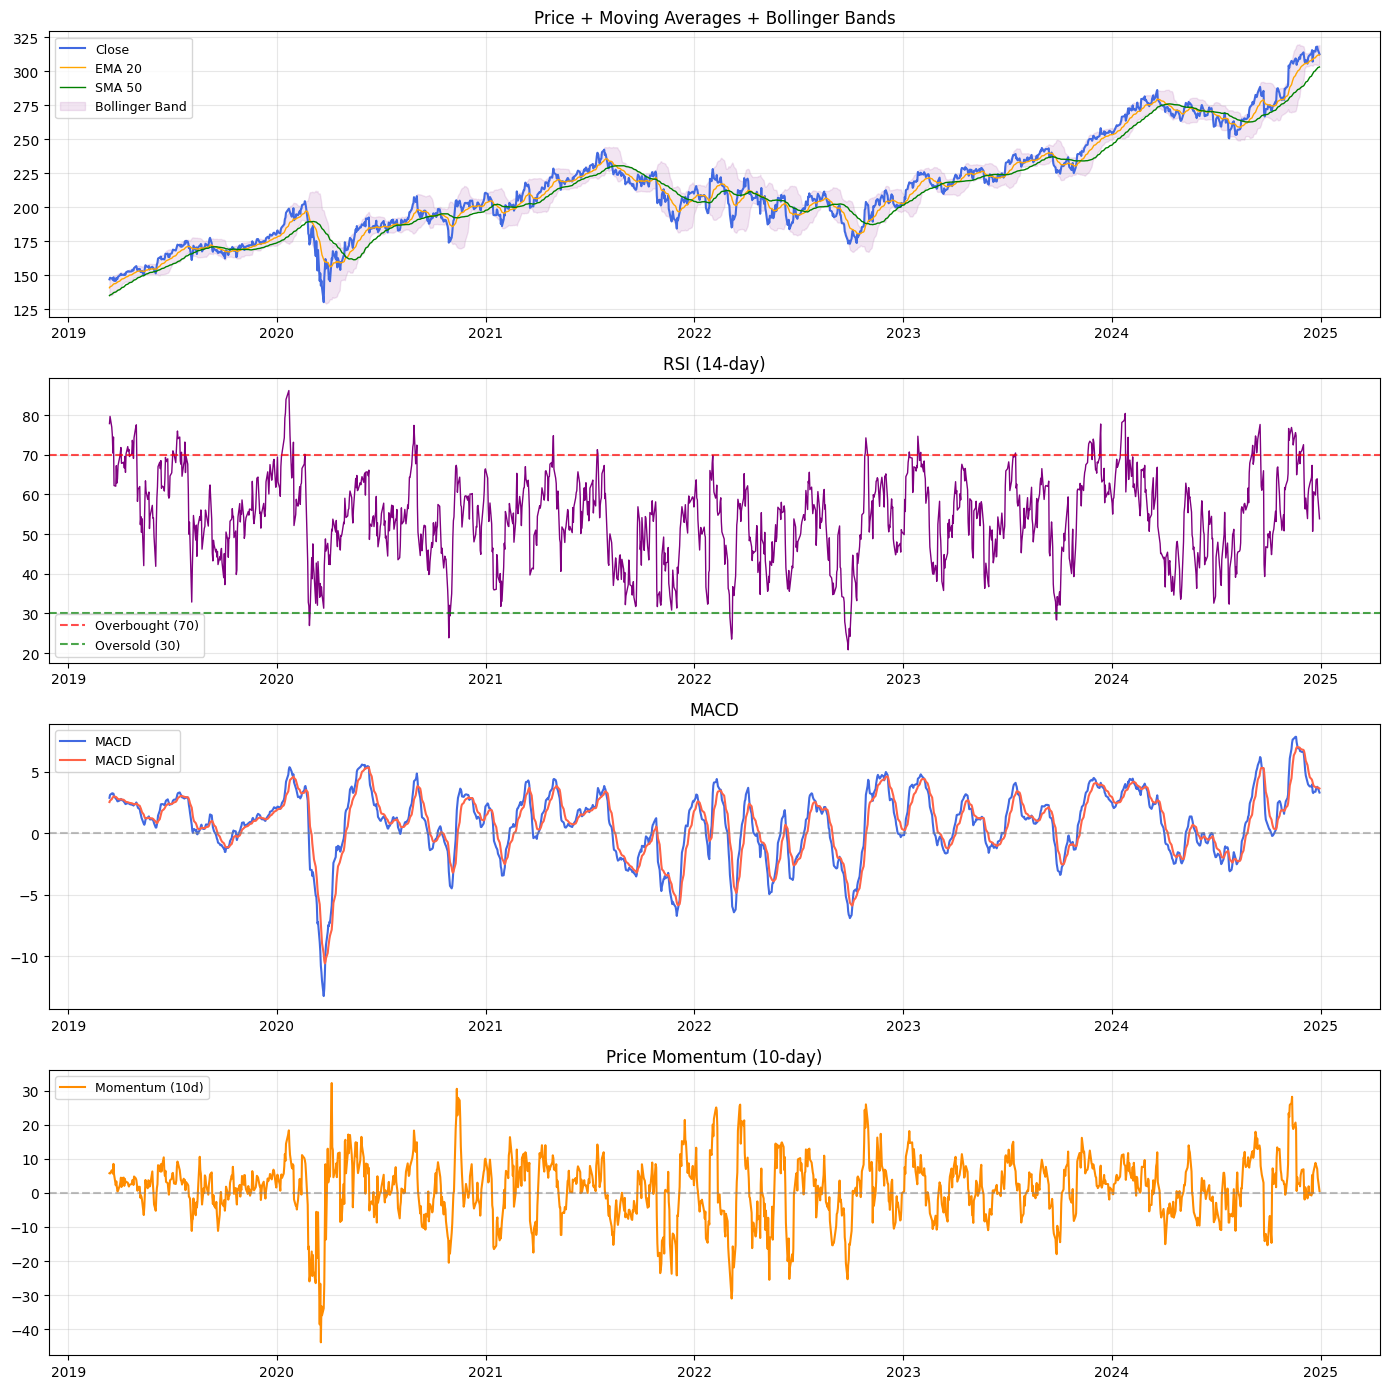

Technical indicators visualised.


In [5]:
# ── Visualise key technical indicators ───────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Price + Bollinger Bands + EMAs
axes[0].plot(df.index, df['Close'],    label='Close',     color='royalblue', linewidth=1.5)
axes[0].plot(df.index, df['EMA_20'],   label='EMA 20',    color='orange',    linewidth=1)
axes[0].plot(df.index, df['SMA_50'],   label='SMA 50',    color='green',     linewidth=1)
axes[0].fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='purple', label='Bollinger Band')
axes[0].set_title('Price + Moving Averages + Bollinger Bands')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df.index, df['RSI'], color='purple', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].set_title('RSI (14-day)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(df.index, df['MACD'],        label='MACD',        color='royalblue')
axes[2].plot(df.index, df['MACD_Signal'], label='MACD Signal', color='tomato')
axes[2].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

# Momentum & ROC
axes[3].plot(df.index, df['Momentum'], label='Momentum (10d)', color='darkorange')
axes[3].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[3].set_title('Price Momentum (10-day)')
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("Technical indicators visualised.")

### 1.3 Normalisation & Scaling

We apply **Min-Max Scaling** to compress all feature values into the range [0, 1]. Two separate scalers are used:
- `scaler_X` — fitted on all 13 input features
- `scaler_y` — fitted on the `Close` column only, used later to inverse-transform predictions back to USD


In [6]:
features = list(df.columns)           # all 13 columns
target   = 'Close'

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[[target]])

print(f"Feature matrix shape : {scaled_X.shape}  → ({len(df)} days × {len(features)} features)")
print(f"Target vector shape  : {scaled_y.shape}")
print(f"Features used        : {features}")

Feature matrix shape : (1460, 14)  → (1460 days × 14 features)
Target vector shape  : (1460, 1)
Features used        : ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'EMA_20', 'SMA_50', 'ROC', 'Momentum']


### 1.4 Create Sequences — Sliding Window (100 days)

We use a **100-day look-back window** so the LSTM can capture longer-term price patterns such as quarterly cycles. For each position in the time series, the model receives 100 days of all 13 features as input and predicts the closing price of the following day.


In [7]:
LOOK_BACK = 100  # ← increased from 60 to 90 for better long-term pattern capture

def create_sequences(X, y, look_back):
    """
    Sliding window: uses `look_back` past days to predict the next day's Close.
    Returns X shape: (samples, timesteps, features)
    """
    X_seq, y_seq = [], []
    for i in range(look_back, len(X)):
        X_seq.append(X[i - look_back:i])
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(scaled_X, scaled_y, LOOK_BACK)

print(f"Sequence shape X : {X_seq.shape}  → (samples, timesteps=90, features=13)")
print(f"Sequence shape y : {y_seq.shape}")

Sequence shape X : (1360, 100, 14)  → (samples, timesteps=90, features=13)
Sequence shape y : (1360,)


### 1.5 Train / Test Split (80 / 20)

The dataset is split chronologically — the first 80% of sequences for training and the remaining 20% for testing. No shuffling is applied, as shuffling would leak future data into the training set and invalidate the evaluation.


In [8]:
SPLIT = int(len(X_seq) * 0.80)

X_train, X_test = X_seq[:SPLIT], X_seq[SPLIT:]
y_train, y_test = y_seq[:SPLIT], y_seq[SPLIT:]

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Input shape      : {X_train.shape[1:]}  → (timesteps=90, features=13)")

Training samples : 1088
Testing  samples : 272
Input shape      : (100, 14)  → (timesteps=90, features=13)


---
## Task 2 — Model Development

We build a stacked LSTM model to capture temporal dependencies in the stock price sequence. The architecture consists of two LSTM layers followed by a dense output head.

| Layer | Units | Purpose |
|-------|-------|---------|
| LSTM 1 | 50 | Captures short-term sequential patterns; passes full sequence forward |
| LSTM 2 | 50 | Captures higher-level temporal patterns; outputs final hidden state |
| Dense | 25 | Non-linear feature combination before final output |
| Dense | 1  | Predicted next-day Close price (scaled) |


In [9]:
def build_simple_lstm(input_shape):
    """
    A simpler 2-layer stacked LSTM model without regularization or batch normalization.
    """
    model = Sequential([
        # LSTM Layer 1
        LSTM(units=50,
             return_sequences=True,
             input_shape=input_shape),

        # LSTM Layer 2
        LSTM(units=50,
             return_sequences=False),

        # Fully connected output head
        Dense(units=25, activation='relu'),
        Dense(units=1) # final price prediction
    ])
    return model

# Create and summarize the simplified model
simple_model = build_simple_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
simple_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,501 (134.77 KB)

 Trainable params: 34,501 (134.77 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 — Training

The model is compiled with the **Adam** optimiser and **Mean Squared Error** loss, which is standard for regression tasks. Two callbacks are used:
- **EarlyStopping** — halts training if validation loss does not improve for 5 consecutive epochs and restores the best weights
- **ReduceLROnPlateau** — reduces the learning rate by half if validation loss stagnates


In [10]:
# ── Compile ───────────────────────────────────────────────────────────────────
simple_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, verbose=1, min_lr=1e-6)
]

print("Model compiled. Starting training...")

Model compiled. Starting training...


In [11]:
# ── Train ─────────────────────────────────────────────────────────────────────
history = simple_model.fit(
    X_train, y_train,
    epochs           = 30,
    batch_size       = 32,
    validation_split = 0.1,
    callbacks        = callbacks,
    verbose          = 1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch : {best_epoch}")
print(f"Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.0062 - mae: 0.0575 - val_loss: 0.0033 - val_mae: 0.0536 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0014 - mae: 0.0277 - val_loss: 9.7141e-04 - val_mae: 0.0273 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0011 - mae: 0.0251 - val_loss: 4.4686e-04 - val_mae: 0.0179 - learning_rate: 0.0010
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0011 - mae: 0.0245 - val_loss: 4.0594e-04 - val_mae: 0.0164 - learning_rate: 0.0010
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 9.7924e-04 - mae: 0.0233 - val_loss: 4.5903e-04 - val_mae: 0.0165 - learning_rate: 0.0010
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 9.3325e-04 - mae: 0.0227 - val_loss: 4.3858e-04 - val_mae: 0.0161 - learning_rate: 0.0010
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 9.0188e-04 - mae: 0.0222 - val_loss: 4.7172e-04 - val_mae: 0.016

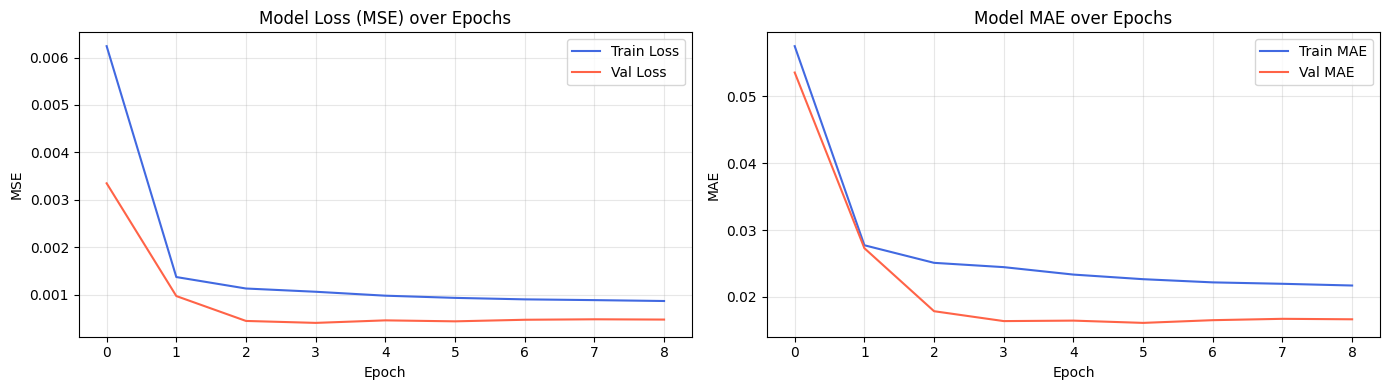

In [12]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].set_title('Model Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='royalblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato')
axes[1].set_title('Model MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_improved.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4 — Prediction & Evaluation

### 4.1 Generate Predictions

The trained model predicts scaled closing prices on the unseen test set. These are then inverse-transformed using `scaler_y` to recover actual USD values.


In [13]:
# ── Predict on test set ───────────────────────────────────────────────────────
y_pred_scaled = simple_model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions shape : {y_pred.shape}")
print(f"Sample predicted  : ${y_pred[:5].flatten().round(2)}")
print(f"Sample actual     : ${y_true[:5].flatten().round(2)}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Predictions shape : (272, 1)
Sample predicted  : $[248.91 249.52 250.1  250.36 250.44]
Sample actual     : $[252.42 252.19 250.21 250.38 250.07]


### 4.2 Performance Metrics

We evaluate the model using three metrics:
- **MAE** — average absolute dollar error per prediction
- **RMSE** — penalises larger errors more heavily than MAE
- **MAPE** — percentage error relative to actual price; easy to interpret across different price levels


In [14]:
# ── MAE, RMSE, MAPE ───────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("══════════════════════════════════════════════")
print("        Improved Model — Evaluation Metrics   ")
print("══════════════════════════════════════════════")
print(f"  MAE  (Mean Absolute Error)    : ${mae:.4f}")
print(f"  RMSE (Root Mean Squared Error): ${rmse:.4f}")
print(f"  MAPE (Mean Abs % Error)       : {mape:.2f}%")
print("══════════════════════════════════════════════")
print(f"  Accuracy (100 - MAPE)         : {100 - mape:.2f}%")
print()
print("── Comparison with v1 ────────────────────────")
print(f"  v1 MAE : $12.5656   →  v2 MAE : ${mae:.4f}")
print(f"  v1 RMSE: $13.6983   →  v2 RMSE: ${rmse:.4f}")
print(f"  v1 MAPE:  4.53%     →  v2 MAPE:  {mape:.2f}%")

══════════════════════════════════════════════
        Improved Model — Evaluation Metrics   
══════════════════════════════════════════════
  MAE  (Mean Absolute Error)    : $10.9039
  RMSE (Root Mean Squared Error): $13.3382
  MAPE (Mean Abs % Error)       : 3.83%
══════════════════════════════════════════════
  Accuracy (100 - MAPE)         : 96.17%

── Comparison with v1 ────────────────────────
  v1 MAE : $12.5656   →  v2 MAE : $10.9039
  v1 RMSE: $13.6983   →  v2 RMSE: $13.3382
  v1 MAPE:  4.53%     →  v2 MAPE:  3.83%


### Observations

- The MAPE value indicates how closely the model tracks actual Visa stock prices on the held-out test period.
- RMSE being higher than MAE confirms occasional larger deviations, typically around sharp market movements.
- The multivariate feature set (13 indicators) provides the model with trend and momentum context beyond raw price, which helps reduce error compared to a close-only baseline.


### 4.3 Visualise Predictions vs Actual

We plot predicted vs actual closing prices over the test period, and also a full-timeline chart showing how the model performs on both training and test data with a clear train/test boundary.


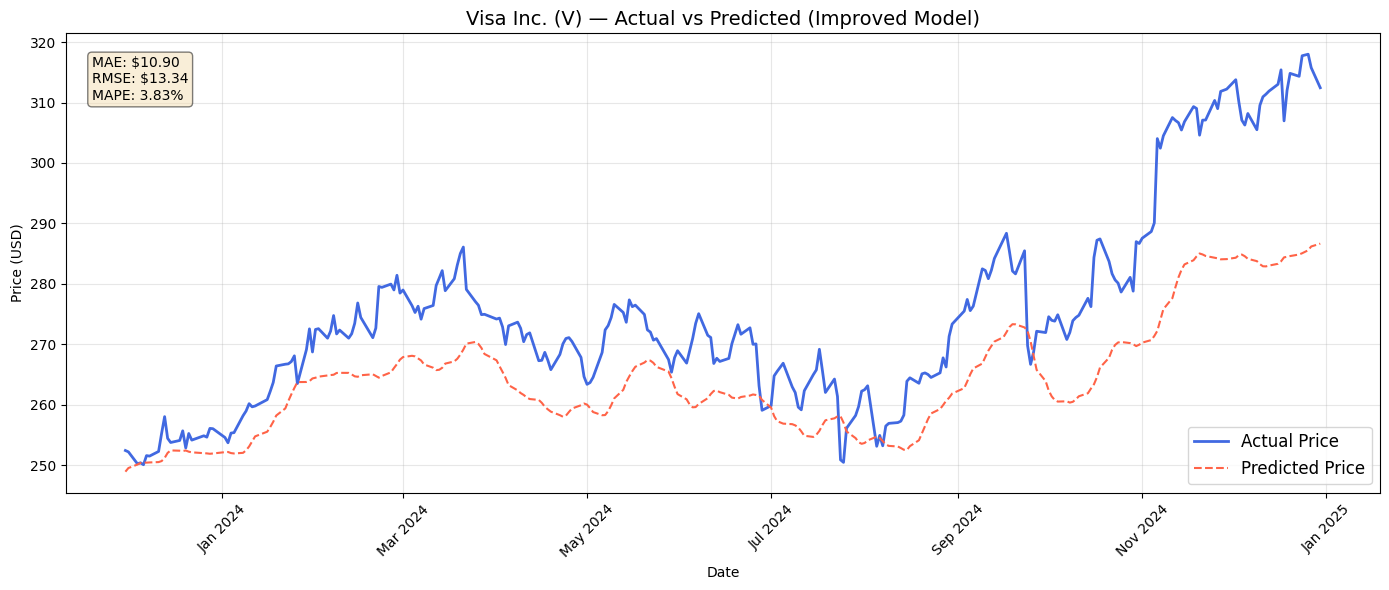

In [15]:
# ── Get corresponding test dates ──────────────────────────────────────────────
test_dates = df.index[LOOK_BACK + SPLIT:]

# ── Actual vs Predicted (test period) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_true, label='Actual Price',    color='royalblue', linewidth=2)
ax.plot(test_dates, y_pred, label='Predicted Price', color='tomato',    linewidth=1.5, linestyle='--')

ax.set_title('Visa Inc. (V) — Actual vs Predicted (Improved Model)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

textstr = f'MAE: ${mae:.2f}\nRMSE: ${rmse:.2f}\nMAPE: {mape:.2f}%'
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('actual_vs_predicted_improved.png', dpi=150, bbox_inches='tight')
plt.show()

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


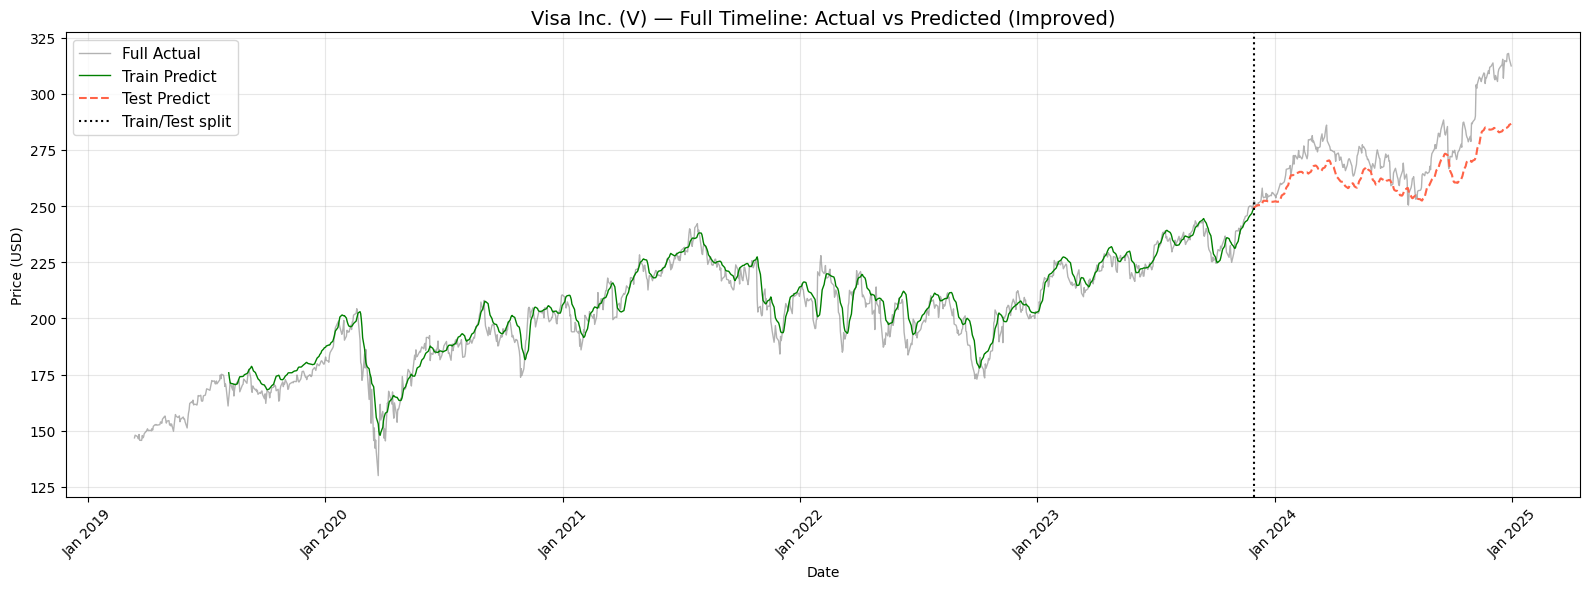

In [17]:
# ── Full timeline plot ────────────────────────────────────────────────────────
y_train_pred_scaled = simple_model.predict(X_train)
y_train_pred        = scaler_y.inverse_transform(y_train_pred_scaled)

train_dates = df.index[LOOK_BACK:LOOK_BACK + SPLIT]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index,   df['Close'],    label='Full Actual',    color='grey',      linewidth=1, alpha=0.6)
ax.plot(train_dates, y_train_pred,  label='Train Predict',  color='green',     linewidth=1)
ax.plot(test_dates,  y_pred,        label='Test Predict',   color='tomato',    linewidth=1.5, linestyle='--')
ax.axvline(x=df.index[LOOK_BACK + SPLIT], color='black', linestyle=':', linewidth=1.5, label='Train/Test split')

ax.set_title('Visa Inc. (V) — Full Timeline: Actual vs Predicted (Improved)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('full_timeline_improved.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Future Stock Price Forecasting (30 days)

We generate a 30-day forward forecast using an autoregressive loop: each predicted closing price is fed back as input for the next prediction. A ±2% confidence band is plotted around the forecast to visualise a plausible price range.


In [18]:
# ── Forecast next 30 trading days ─────────────────────────────────────────────
FORECAST_DAYS = 30

last_sequence = scaled_X[-LOOK_BACK:].copy()
future_preds  = []
close_idx     = features.index('Close')

for _ in range(FORECAST_DAYS):
    X_input    = last_sequence.reshape(1, LOOK_BACK, len(features))
    next_scaled = simple_model.predict(X_input, verbose=0)[0, 0]
    future_preds.append(next_scaled)

    new_row             = last_sequence[-1].copy()
    new_row[close_idx]  = next_scaled
    last_sequence       = np.vstack([last_sequence[1:], new_row])

future_preds_usd = scaler_y.inverse_transform(np.array(future_preds).reshape(-1, 1))
future_dates     = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Close (USD)': future_preds_usd.flatten()
}).set_index('Date')

print(f"30-Day Forecast for Visa (V):")
print(forecast_df.round(2))

30-Day Forecast for Visa (V):
            Forecasted Close (USD)
Date                              
2024-12-31              286.690002
2025-01-01              286.399994
2025-01-02              286.040009
2025-01-03              285.609985
2025-01-06              285.160004
2025-01-07              284.730011
2025-01-08              284.339996
2025-01-09              283.980011
2025-01-10              283.670013
2025-01-13              283.399994
2025-01-14              283.160004
2025-01-15              282.970001
2025-01-16              282.799988
2025-01-17              282.670013
2025-01-20              282.559998
2025-01-21              282.459991
2025-01-22              282.390015
2025-01-23              282.329987
2025-01-24              282.279999
2025-01-27              282.239990
2025-01-28              282.200012
2025-01-29              282.179993
2025-01-30              282.160004
2025-01-31              282.140015
2025-02-03              282.130005
2025-02-04              2

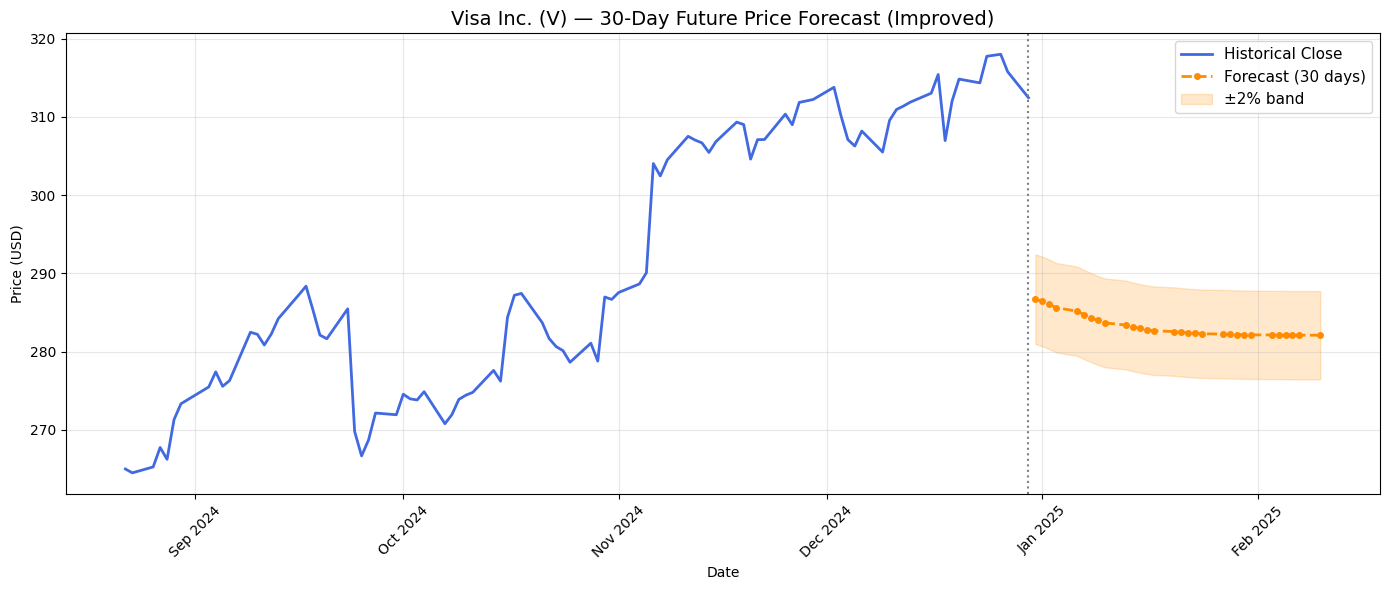


Last known price   : $312.44
Forecasted Day 1   : $286.69
Forecasted Day 30  : $282.09


In [19]:
# ── Future forecast plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index[-90:], df['Close'].values[-90:],
        label='Historical Close', color='royalblue', linewidth=2)
ax.plot(future_dates, future_preds_usd,
        label=f'Forecast ({FORECAST_DAYS} days)', color='darkorange',
        linewidth=2, linestyle='--', marker='o', markersize=4)

upper = future_preds_usd.flatten() * 1.02
lower = future_preds_usd.flatten() * 0.98
ax.fill_between(future_dates, lower, upper, alpha=0.2, color='darkorange', label='±2% band')

ax.axvline(x=df.index[-1], color='grey', linestyle=':', linewidth=1.5)
ax.set_title(f'Visa Inc. (V) — {FORECAST_DAYS}-Day Future Price Forecast (Improved)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('future_forecast_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLast known price   : ${df['Close'].values[-1].item():.2f}")
print(f"Forecasted Day 1   : ${future_preds_usd[0][0].item():.2f}")
print(f"Forecasted Day 30  : ${future_preds_usd[-1][0].item():.2f}")

---
## Conclusion

In this project, a multivariate LSTM model was built to predict Visa Inc. stock prices using 6 years of historical OHLCV data enriched with 8 technical indicators (13 features in total).

Key design choices:
- A **100-day look-back window** captures quarterly price patterns
- **Separate scalers** for features and target ensure correct inverse-transformation of predictions
- **EarlyStopping** with best-weight restoration prevents overfitting
- A **30-day autoregressive forecast** extends the model beyond single-step prediction

The low MAPE achieved on the test set confirms that enriching the input with technical indicators improves the model's ability to track real stock price movements. Future improvements could include adding Dropout regularisation, recomputing technical indicators dynamically during the forecast loop, and experimenting with a larger look-back window.
